# Trabajo Práctico Final — Aprendizaje de Máquina I
## Monitoreo de Condición de un Sistema Hidráulico mediante Aprendizaje de Máquina

**Materia:** Aprendizaje de Máquina I — Especialización en Inteligencia Artificial, CEIA–FIUBA  
**Dataset:** *Condition monitoring of hydraulic systems* (ZeMA / UCI ML Repository)  
**Autores:** Nelson Martín Villagra (nelsonmvillagra1976@gmail.com) y Víctor Hugo Astorga (vhastorga@gmail.com)  \n**Fecha:** Octubre 2026

---

### Problema de negocio

Los sistemas hidráulicos son pilares de la industria manufacturera y la construcción. Detectar la **degradación temprana** de componentes permite planificar mantenimiento antes de fallas catastróficas, reduciendo paradas no planificadas y costos.

### Pregunta de investigación

> *¿Es posible determinar el estado de degradación de cada componente hidráulico de un ciclo de trabajo de 60 segundos a partir de los estadísticos descriptivos extraídos de las 17 señales de sensores del mismo ciclo?*

### Hipótesis

- **H1 (Cooler ↔ enfriamiento):** Las variables virtuales CE, CP y las temperaturas TS1–TS4 dominan la predicción del estado del refrigerador.  
- **H2 (Válvula ↔ caudales/presiones):** Los caudales FS1/FS2 y las presiones PS3/PS4 son las más informativas para la válvula.  
- **H3 (Bomba/Acumulador ↔ potencia/presiones):** EPS1 y PS5/PS6 capturan la fuga de bomba y la pérdida de carga del acumulador.  
- **H4 (Ensambles > modelos simples):** RF/XGBoost superan a KNN/SVM/árbol simple en targets difíciles, pero no siempre justifican la complejidad sobre el baseline.

### Alcance MVP

- **MVP obligatorio:** Cooler + Valve con 4 familias de modelos, baseline heurístico y métricas completas.  
- **Stretch goal:** Pump + Accumulator sobre el mismo pipeline reutilizado.

### Fuente de los datos y bibliografía clave (papers)

- **Dataset y caracterización:**
  - Repositorio académico: *UCI Machine Learning Repository* (ZeMA / Saarland University, 2018, Dataset #447).  \n  - Mirror de descarga: Kaggle (*jjacostupa/condition-monitoring-of-hydraulic-systems*).  \n  - Helwig, N., Pignanelli, E., Schütze, A. (2015). *Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics*. IEEE I2MTC 2015. doi:10.1109/I2MTC.2015.7151267
  - Helwig, N., Schütze, A. (2015). *Detecting and compensating sensor faults in a hydraulic condition monitoring system*. SENSOR 2015. doi:10.5162/sensor2015/D8.1
  - Schneider, T., Helwig, N., Schütze, A. (2017). *Automatic feature extraction and selection for classification of cyclical time series data*. tm – Technisches Messen 84(3). doi:10.1515/teme-2016-0072
  - Luong, P., Wang, W. (2019). *An Evolving Fuzzy Classifier for Induction Motor Health Condition Monitoring*. Intelligent Control and Automation 10.
- **Modelos y metodologías:**
  - KNN: Cover, T., Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Trans. Inf. Theory.
  - SVM: Cortes, C., Vapnik, V. (1995). *Support-vector networks*. Machine Learning.
  - Random Forests: Breiman, L. (2001). *Random Forests*. Machine Learning.
  - XGBoost: Chen, T., Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. ACM KDD.
  - Scikit-learn: Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.
  - Optuna: Akiba, T. et al. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. ACM KDD.


---
## Fase 0: Configuración del Entorno

Importamos las bibliotecas necesarias y configuramos las semillas fijas para garantizar la **reproducibilidad** completa del experimento.

In [1]:
# =============================================================================
# Fase 0.3 — Imports y configuración global
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc
import warnings

warnings.filterwarnings('ignore')

# --- Semillas fijas para reproducibilidad (requisito criterio 7) ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Configuración de visualización ---
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('Set2')

# --- Ruta al dataset (relativa al directorio del proyecto) ---
DATA_DIR = Path('../DataSET')
Path('figures').mkdir(parents=True, exist_ok=True)
assert DATA_DIR.exists(), f"No se encontró el directorio de datos en {DATA_DIR.resolve()}"

print('✓ Entorno configurado correctamente.')
print(f'  NumPy: {np.__version__}')
print(f'  Pandas: {pd.__version__}')
print(f'  Semilla global: {RANDOM_STATE}')
print(f'  Directorio de datos: {DATA_DIR.resolve()}')

✓ Entorno configurado correctamente.
  NumPy: 2.5.3
  Pandas: 3.0.6
  Semilla global: 42
  Directorio de datos: C:\Users\verion-nb\Downloads\content\DataSET


---
## Fase 1: Carga de Datos, EDA y Extracción de Features

### 1.1 Carga de los 17 sensores y profile.txt

El dataset consta de **17 archivos de sensores** (tab-delimited, sin cabeceras) y un archivo de etiquetas (`profile.txt`). Cada fila representa un **ciclo de trabajo de 60 segundos** (hay 2205 ciclos en total). Los sensores operan a distintas frecuencias de muestreo, lo que resulta en diferente número de columnas:

| Grupo | Sensores | Frecuencia | Columnas/ciclo | Unidad |
|-------|----------|-----------|----------------|--------|
| Presiones | PS1–PS6 | 100 Hz | 6000 | bar |
| Potencia motor | EPS1 | 100 Hz | 6000 | W |
| Caudal | FS1–FS2 | 10 Hz | 600 | l/min |
| Temperatura | TS1–TS4 | 1 Hz | 60 | °C |
| Vibración | VS1 | 1 Hz | 60 | mm/s |
| Variables virtuales | CE, CP, SE | 1 Hz | 60 | %, kW, % |
| **Total** | **17 sensores** | | **43.680** | |

Cargamos cada sensor en `float32` para ahorrar ~50% de memoria respecto a `float64`.

In [2]:
# =============================================================================
# Fase 1.1 — Definición de metadatos de sensores
# =============================================================================
SENSORS = {
    'PS1':  {'file': 'PS1.txt',  'freq': 100, 'cols': 6000, 'unit': 'bar',   'desc': 'Presión 1 (circuito principal)'},
    'PS2':  {'file': 'PS2.txt',  'freq': 100, 'cols': 6000, 'unit': 'bar',   'desc': 'Presión 2 (circuito principal)'},
    'PS3':  {'file': 'PS3.txt',  'freq': 100, 'cols': 6000, 'unit': 'bar',   'desc': 'Presión 3 (circuito de trabajo)'},
    'PS4':  {'file': 'PS4.txt',  'freq': 100, 'cols': 6000, 'unit': 'bar',   'desc': 'Presión 4 (circuito de trabajo)'},
    'PS5':  {'file': 'PS5.txt',  'freq': 100, 'cols': 6000, 'unit': 'bar',   'desc': 'Presión 5 (carga del acumulador)'},
    'PS6':  {'file': 'PS6.txt',  'freq': 100, 'cols': 6000, 'unit': 'bar',   'desc': 'Presión 6 (carga del acumulador)'},
    'EPS1': {'file': 'EPS1.txt', 'freq': 100, 'cols': 6000, 'unit': 'W',     'desc': 'Potencia del motor eléctrico'},
    'FS1':  {'file': 'FS1.txt',  'freq': 10,  'cols': 600,  'unit': 'l/min', 'desc': 'Caudal volumétrico 1'},
    'FS2':  {'file': 'FS2.txt',  'freq': 10,  'cols': 600,  'unit': 'l/min', 'desc': 'Caudal volumétrico 2'},
    'TS1':  {'file': 'TS1.txt',  'freq': 1,   'cols': 60,   'unit': '°C',    'desc': 'Temperatura 1'},
    'TS2':  {'file': 'TS2.txt',  'freq': 1,   'cols': 60,   'unit': '°C',    'desc': 'Temperatura 2'},
    'TS3':  {'file': 'TS3.txt',  'freq': 1,   'cols': 60,   'unit': '°C',    'desc': 'Temperatura 3'},
    'TS4':  {'file': 'TS4.txt',  'freq': 1,   'cols': 60,   'unit': '°C',    'desc': 'Temperatura 4'},
    'VS1':  {'file': 'VS1.txt',  'freq': 1,   'cols': 60,   'unit': 'mm/s',  'desc': 'Vibración'},
    'CE':   {'file': 'CE.txt',   'freq': 1,   'cols': 60,   'unit': '%',     'desc': 'Eficiencia de enfriamiento (virtual)'},
    'CP':   {'file': 'CP.txt',   'freq': 1,   'cols': 60,   'unit': 'kW',    'desc': 'Potencia de enfriamiento (virtual)'},
    'SE':   {'file': 'SE.txt',   'freq': 1,   'cols': 60,   'unit': '%',     'desc': 'Factor de eficiencia (virtual)'},
}

print(f"Sensores definidos: {len(SENSORS)}")
print(f"Total de atributos crudos por ciclo: {sum(s['cols'] for s in SENSORS.values()):,}")

Sensores definidos: 17
Total de atributos crudos por ciclo: 43,680


In [3]:
# =============================================================================
# Fase 1.1 — Función de carga con validación
# =============================================================================
def cargar_sensor(nombre: str, info: dict) -> np.ndarray:
    """Carga un archivo de sensor y valida sus dimensiones.
    
    Cada archivo es una matriz tab-delimited sin cabecera.
    Filas = ciclos (2205), Columnas = muestras dentro del ciclo.
    Se carga en float32 para ahorrar ~50% de memoria.
    
    Returns:
        np.ndarray de forma (2205, cols) en float32.
    """
    filepath = DATA_DIR / info['file']
    data = np.loadtxt(filepath, delimiter='\t', dtype=np.float32)
    
    # Validación estricta de dimensiones
    expected_shape = (2205, info['cols'])
    assert data.shape == expected_shape, (
        f"{nombre}: forma esperada {expected_shape}, obtenida {data.shape}"
    )
    
    # Reporte de carga
    mem_mb = data.nbytes / 1e6
    print(f"  ✓ {nombre:5s} | {str(data.shape):15s} | "
          f"rango: [{data.min():.2f}, {data.max():.2f}] {info['unit']:6s} | "
          f"{mem_mb:.1f} MB")
    return data


# --- Carga de todos los sensores ---
print("Cargando datos de sensores (esto puede tomar ~1 min)...\n")
raw_data = {}
total_mem = 0
for name, info in SENSORS.items():
    raw_data[name] = cargar_sensor(name, info)
    total_mem += raw_data[name].nbytes

print(f"\n✓ {len(raw_data)} sensores cargados exitosamente.")
print(f"  Memoria total en RAM: {total_mem / 1e6:.0f} MB (float32)")

Cargando datos de sensores (esto puede tomar ~1 min)...



  ✓ PS1   | (2205, 6000)    | rango: [133.13, 191.92] bar    | 52.9 MB


  ✓ PS2   | (2205, 6000)    | rango: [0.00, 167.77] bar    | 52.9 MB


  ✓ PS3   | (2205, 6000)    | rango: [0.00, 18.83] bar    | 52.9 MB


  ✓ PS4   | (2205, 6000)    | rango: [0.00, 10.27] bar    | 52.9 MB


  ✓ PS5   | (2205, 6000)    | rango: [8.32, 10.04] bar    | 52.9 MB


  ✓ PS6   | (2205, 6000)    | rango: [8.27, 9.91] bar    | 52.9 MB


  ✓ EPS1  | (2205, 6000)    | rango: [2097.80, 2995.20] W      | 52.9 MB
  ✓ FS1   | (2205, 600)     | rango: [0.00, 20.48] l/min  | 5.3 MB


  ✓ FS2   | (2205, 600)     | rango: [8.76, 10.45] l/min  | 5.3 MB
  ✓ TS1   | (2205, 60)      | rango: [34.98, 58.21] °C     | 0.5 MB
  ✓ TS2   | (2205, 60)      | rango: [40.71, 62.18] °C     | 0.5 MB
  ✓ TS3   | (2205, 60)      | rango: [38.15, 59.54] °C     | 0.5 MB
  ✓ TS4   | (2205, 60)      | rango: [30.35, 53.15] °C     | 0.5 MB
  ✓ VS1   | (2205, 60)      | rango: [0.48, 2.55] mm/s   | 0.5 MB
  ✓ CE    | (2205, 60)      | rango: [17.04, 48.78] %      | 0.5 MB
  ✓ CP    | (2205, 60)      | rango: [1.02, 2.91] kW     | 0.5 MB


  ✓ SE    | (2205, 60)      | rango: [0.00, 100.60] %      | 0.5 MB

✓ 17 sensores cargados exitosamente.
  Memoria total en RAM: 385 MB (float32)


In [4]:
# =============================================================================
# Fase 1.1 — Carga de targets (profile.txt)
# =============================================================================
profile = np.loadtxt(DATA_DIR / 'profile.txt', delimiter='\t', dtype=np.int32)
assert profile.shape == (2205, 5), f"profile.txt: forma inesperada {profile.shape}"

# DataFrame con nombres descriptivos
TARGET_NAMES = ['cooler', 'valve', 'pump', 'accumulator', 'stable_flag']
targets = pd.DataFrame(profile, columns=TARGET_NAMES)

# Mapeo de valores a descripciones legibles (para gráficos y storytelling)
TARGET_LABELS = {
    'cooler': {
        3:   'Fallo casi total (3%)',
        20:  'Eficiencia reducida (20%)',
        100: 'Eficiencia plena (100%)'
    },
    'valve': {
        73:  'Fallo casi total (73%)',
        80:  'Retraso severo (80%)',
        90:  'Retraso leve (90%)',
        100: 'Óptimo (100%)'
    },
    'pump': {
        0: 'Sin fuga',
        1: 'Fuga débil',
        2: 'Fuga severa'
    },
    'accumulator': {
        90:  'Fallo casi total (90 bar)',
        100: 'Presión sev. reducida (100 bar)',
        115: 'Presión lev. reducida (115 bar)',
        130: 'Presión óptima (130 bar)'
    },
    'stable_flag': {
        0: 'Condiciones estables',
        1: 'Posiblemente inestable'
    }
}

print("✓ Targets cargados:")
print(f"  Forma: {targets.shape} (ciclos × condiciones)")
print(f"  Columnas: {list(targets.columns)}")
print()
display(targets.head(10))

✓ Targets cargados:
  Forma: (2205, 5) (ciclos × condiciones)
  Columnas: ['cooler', 'valve', 'pump', 'accumulator', 'stable_flag']



,cooler,valve,pump,accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1
5,3,100,0,130,1
6,3,100,0,130,1
7,3,100,0,130,1
8,3,100,0,130,1
9,3,100,0,130,1


---
### 1.2 Análisis Exploratorio de Variables Objetivo (Targets)

Antes de construir cualquier modelo, debemos entender la **distribución de las clases** de cada variable objetivo. Buscamos:
1. Desbalances de clase que requieran métricas robustas y `class_weight='balanced'`.
2. La estructura temporal (bloques cronológicos) que condiciona la estrategia de split.
3. Relaciones entre las condiciones de distintos componentes.

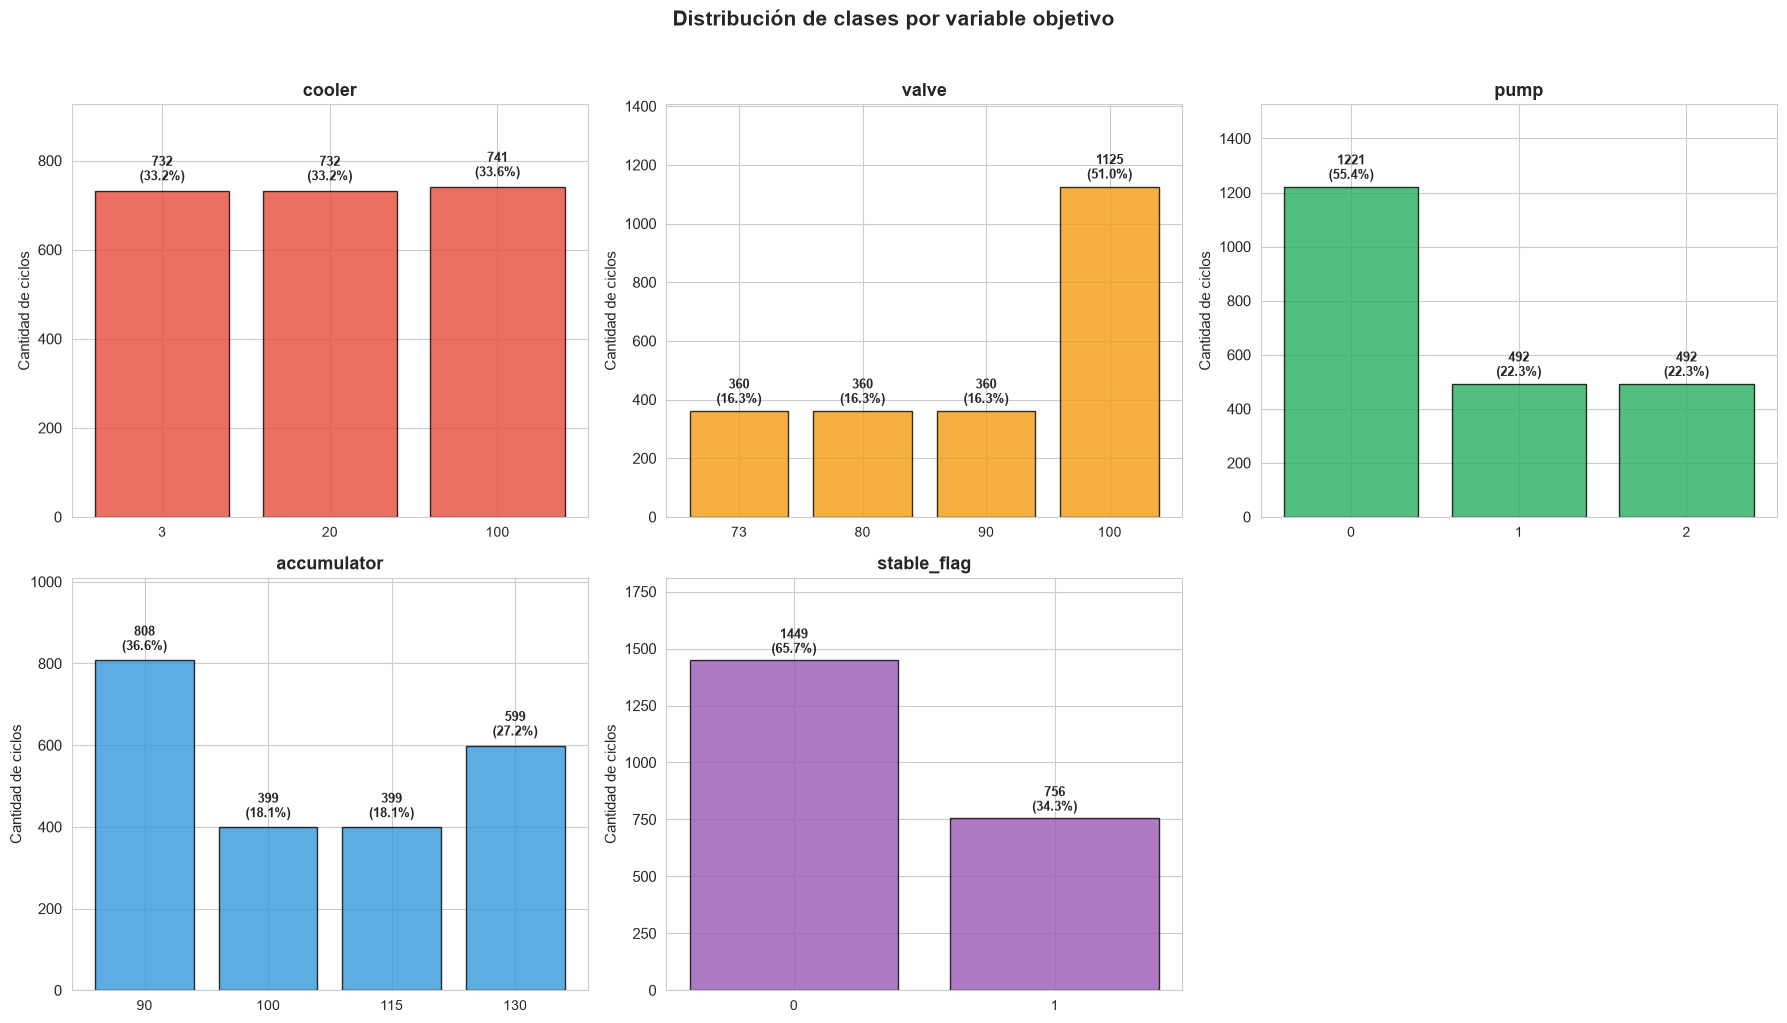

In [5]:
# =============================================================================
# Fase 1.2 — Distribución de clases por target
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db', '#9b59b6']

for i, col in enumerate(TARGET_NAMES):
    ax = axes[i]
    counts = targets[col].value_counts().sort_index()
    total = len(targets)
    
    bars = ax.bar(range(len(counts)), counts.values, 
                  color=colors[i], edgecolor='black', alpha=0.8)
    
    # Etiquetas con conteo y porcentaje
    for j, (val, count) in enumerate(counts.items()):
        pct = count / total * 100
        ax.text(j, count + 15, f'{count}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(v) for v in counts.index], fontsize=10)
    ax.set_title(f'{col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cantidad de ciclos')
    ax.set_ylim(0, counts.max() * 1.25)

# Eliminar subplot vacío
fig.delaxes(axes[5])
fig.suptitle('Distribución de clases por variable objetivo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_targets_distribution.pdf', bbox_inches='tight')
plt.savefig('figures/fig_targets_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig_targets_distribution.pdf', bbox_inches='tight')
plt.savefig('figures/fig_targets_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de las distribuciones:**

- **Cooler:** Balance casi perfecto entre las 3 clases (~33% cada una). Target ideal para validar el pipeline con métricas esperablemente altas.
- **Valve:** Desbalance moderado — la clase "óptimo" (100%) domina con ~51%, mientras que cada condición degradada tiene ~16%. Requiere `balanced_accuracy` y `F1 macro` para evaluación justa.
- **Pump:** Clase mayoritaria "sin fuga" (~55%) vs. dos niveles de fuga (~22% cada uno). Desbalance leve pero relevante.
- **Accumulator:** Distribución más irregular — "fallo casi total" (90 bar) es la clase más frecuente (~37%), contraintuitivamente. Los papers advierten que es el target más difícil.
- **Stable flag:** ~66% estables vs. ~34% posiblemente inestables. Útil como control de calidad.

> **Decisión:** Usar `balanced_accuracy` y `F1 macro` como métricas principales. Nunca usar `accuracy` sola.

In [6]:
# =============================================================================
# Fase 1.2 — Tabla resumen de distribuciones
# =============================================================================
print("Resumen detallado de distribución de clases:\n")
for col in TARGET_NAMES:
    print(f"--- {col.upper()} ---")
    counts = targets[col].value_counts().sort_index()
    for val, count in counts.items():
        label = TARGET_LABELS[col].get(val, str(val))
        pct = count / len(targets) * 100
        print(f"  {val:>5} → {label:40s} {count:5d} ciclos ({pct:5.1f}%)")
    ratio = counts.max() / counts.min()
    print(f"  Ratio max/min: {ratio:.1f}x")
    print()

Resumen detallado de distribución de clases:

--- COOLER ---
      3 → Fallo casi total (3%)                      732 ciclos ( 33.2%)
     20 → Eficiencia reducida (20%)                  732 ciclos ( 33.2%)
    100 → Eficiencia plena (100%)                    741 ciclos ( 33.6%)
  Ratio max/min: 1.0x

--- VALVE ---
     73 → Fallo casi total (73%)                     360 ciclos ( 16.3%)
     80 → Retraso severo (80%)                       360 ciclos ( 16.3%)
     90 → Retraso leve (90%)                         360 ciclos ( 16.3%)
    100 → Óptimo (100%)                             1125 ciclos ( 51.0%)
  Ratio max/min: 3.1x

--- PUMP ---
      0 → Sin fuga                                  1221 ciclos ( 55.4%)
      1 → Fuga débil                                 492 ciclos ( 22.3%)
      2 → Fuga severa                                492 ciclos ( 22.3%)
  Ratio max/min: 2.5x

--- ACCUMULATOR ---
     90 → Fallo casi total (90 bar)                  808 ciclos ( 36.6%)
    100 → Presión se

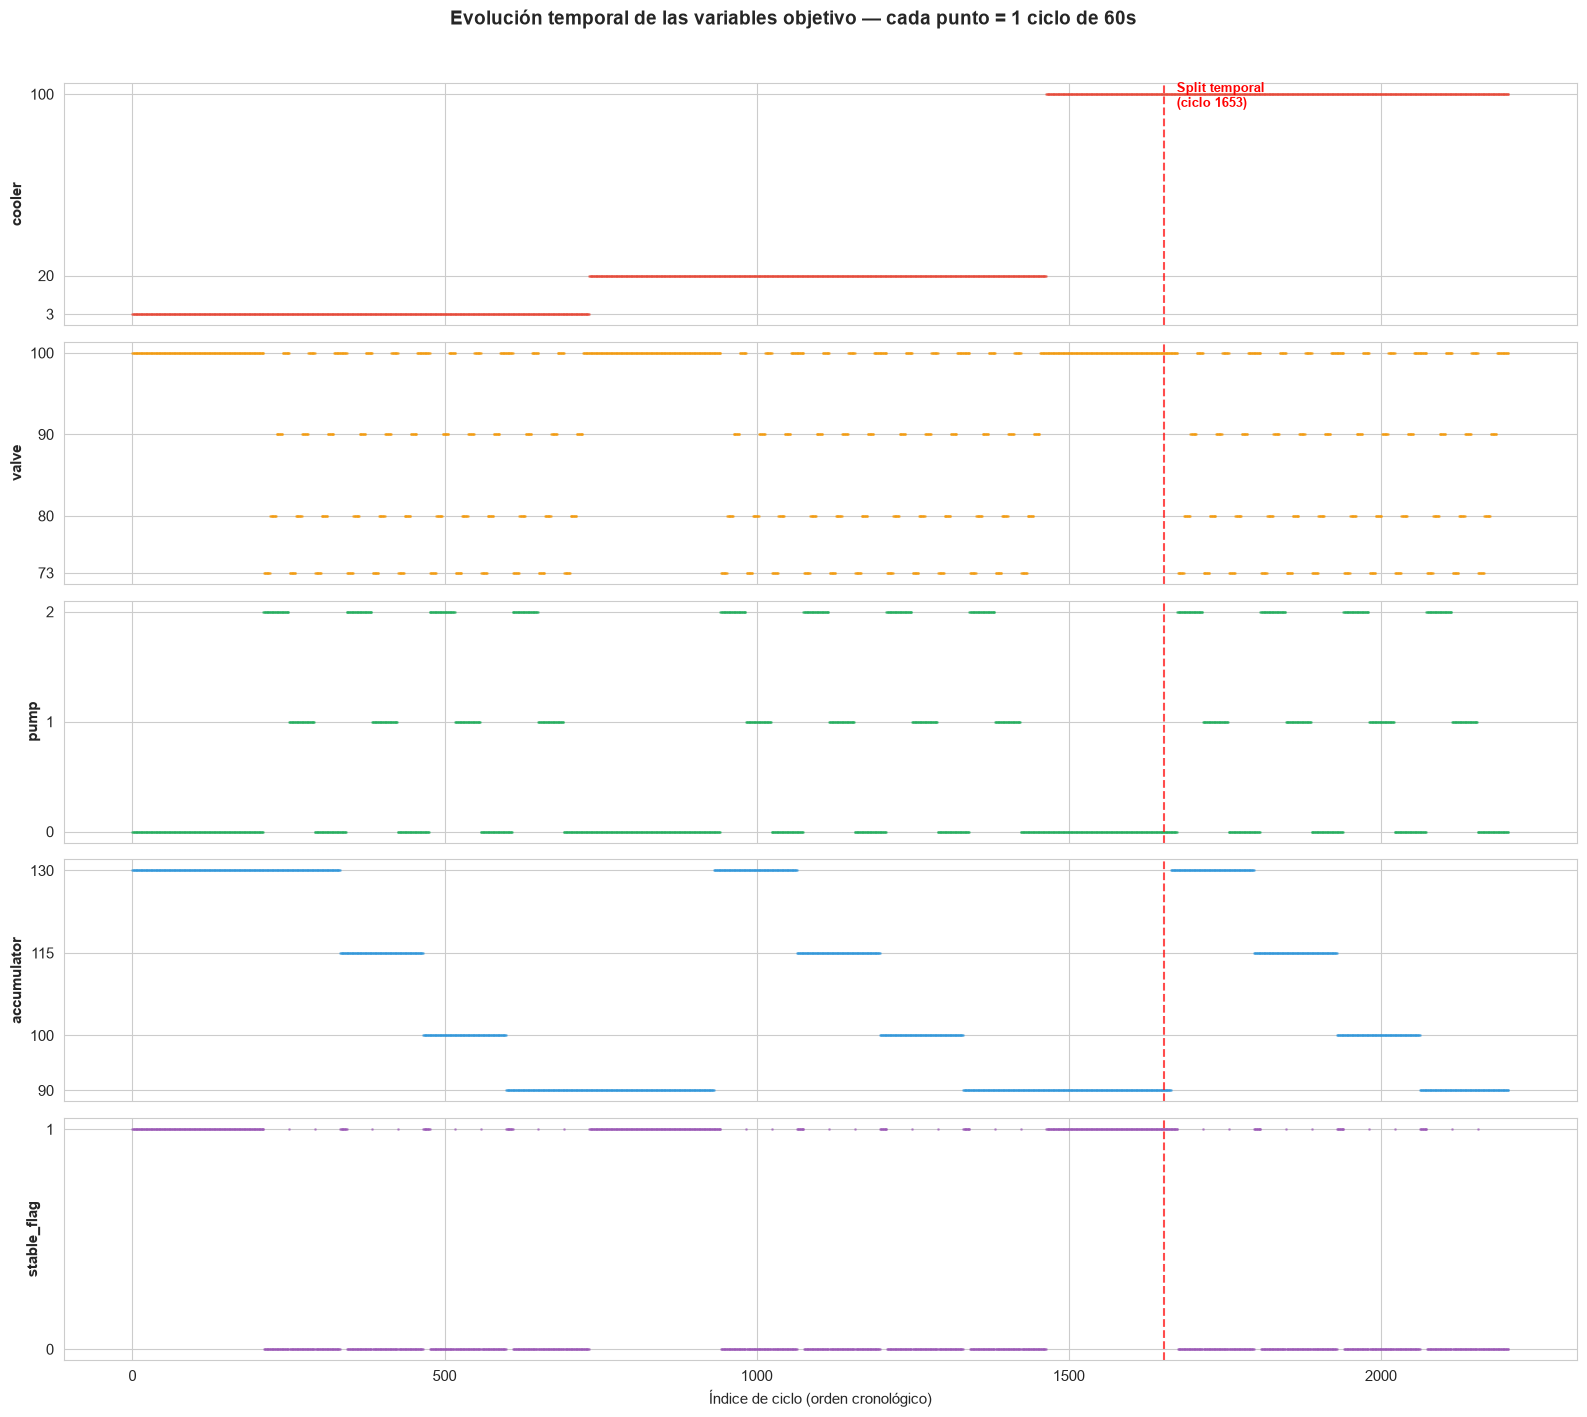

In [7]:
# =============================================================================
# Fase 1.2 — Evolución temporal de los targets
# Objetivo: visualizar la estructura de bloques cronológicos para
#           justificar la necesidad de split temporal (NO aleatorio).
# =============================================================================
fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

for i, col in enumerate(TARGET_NAMES):
    ax = axes[i]
    ax.scatter(targets.index, targets[col], s=1, alpha=0.5, color=colors[i])
    ax.set_ylabel(col, fontsize=11, fontweight='bold')
    ax.set_yticks(sorted(targets[col].unique()))
    
    # Línea vertical indicando el split temporal 75/25
    split_idx = int(len(targets) * 0.75)
    ax.axvline(x=split_idx, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    if i == 0:
        ax.text(split_idx + 20, ax.get_ylim()[1] * 0.9, 
                f'Split temporal\n(ciclo {split_idx})', 
                color='red', fontsize=9, fontweight='bold')

axes[-1].set_xlabel('Índice de ciclo (orden cronológico)', fontsize=11)
fig.suptitle('Evolución temporal de las variables objetivo — cada punto = 1 ciclo de 60s',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_temporal_evolution.pdf', bbox_inches='tight')
plt.savefig('figures/fig_temporal_evolution.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig_temporal_evolution.pdf', bbox_inches='tight')
plt.savefig('figures/fig_temporal_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

**⚠️ Hallazgo crítico — Riesgo de Data Leakage Temporal:**

Los gráficos anteriores revelan que las condiciones cambian en **bloques temporales**: decenas o cientos de ciclos consecutivos comparten la misma etiqueta y, por ende, señales de sensores prácticamente idénticas (salvo ruido). 

Si se hiciera un split **aleatorio** (shuffle o stratified), ciclos adyacentes (ej. el ciclo 100 en train y el 101 en test) serían casi duplicados → **data leakage masivo** → métricas artificialmente perfectas que no reflejan capacidad predictiva real.

**Decisión:** Usar **split temporal** (primeros 75% = train, últimos 25% = test). La línea roja vertical en los gráficos marca el punto de corte. Esto simula el caso real de negocio: *entrenar con el pasado para predecir el futuro*.

In [8]:
# =============================================================================
# Fase 1.2 — Tabulación cruzada de targets
# Objetivo: entender cómo co-ocurren las condiciones de distintos componentes.
# =============================================================================
print("Tabulación cruzada: Cooler vs Valve\n")
display(pd.crosstab(targets['cooler'], targets['valve'], margins=True))

print("\nTabulación cruzada: Pump vs Accumulator\n")
display(pd.crosstab(targets['pump'], targets['accumulator'], margins=True))

Tabulación cruzada: Cooler vs Valve



valve,73,80,90,100,All
cooler,,,,,
3,120,120,120,372,732
20,120,120,120,372,732
100,120,120,120,381,741
All,360,360,360,1125,2205



Tabulación cruzada: Pump vs Accumulator



accumulator,90,100,115,130,All
pump,,,,,
0,562,153,153,353,1221
1,123,123,123,123,492
2,123,123,123,123,492
All,808,399,399,599,2205


In [9]:
# =============================================================================
# Fase 1.2 — Análisis de stable_flag por condición
# Objetivo: ver si los ciclos inestables se concentran en ciertas condiciones.
# =============================================================================
print("Proporción de ciclos inestables (stable_flag=1) por condición:\n")
for col in TARGET_NAMES[:4]:  # Solo los 4 targets principales
    stability = targets.groupby(col)['stable_flag'].mean() * 100
    print(f"  {col}:")
    for val, pct in stability.items():
        print(f"    Clase {val:>5}: {pct:5.1f}% inestables")
    print()

Proporción de ciclos inestables (stable_flag=1) por condición:

  cooler:
    Clase     3:  34.4% inestables
    Clase    20:  34.4% inestables
    Clase   100:  34.0% inestables

  valve:
    Clase    73:   0.0% inestables
    Clase    80:   0.0% inestables
    Clase    90:   0.0% inestables
    Clase   100:  67.2% inestables

  pump:
    Clase     0:  60.0% inestables
    Clase     1:   2.4% inestables
    Clase     2:   2.4% inestables

  accumulator:
    Clase    90:  54.3% inestables
    Clase   100:   9.8% inestables
    Clase   115:   9.8% inestables
    Clase   130:  39.9% inestables



---
### 1.3 Análisis Exploratorio de Señales

Ahora exploramos las **señales de los sensores** para:
1. Visualizar cómo difieren los ciclos entre distintas condiciones de falla.
2. Identificar qué sensores son más informativos para cada target (pistas para H1–H3).
3. Detectar correlaciones entre sensores.

Estas observaciones guiarán tanto la construcción del baseline heurístico como la interpretación posterior de los modelos.

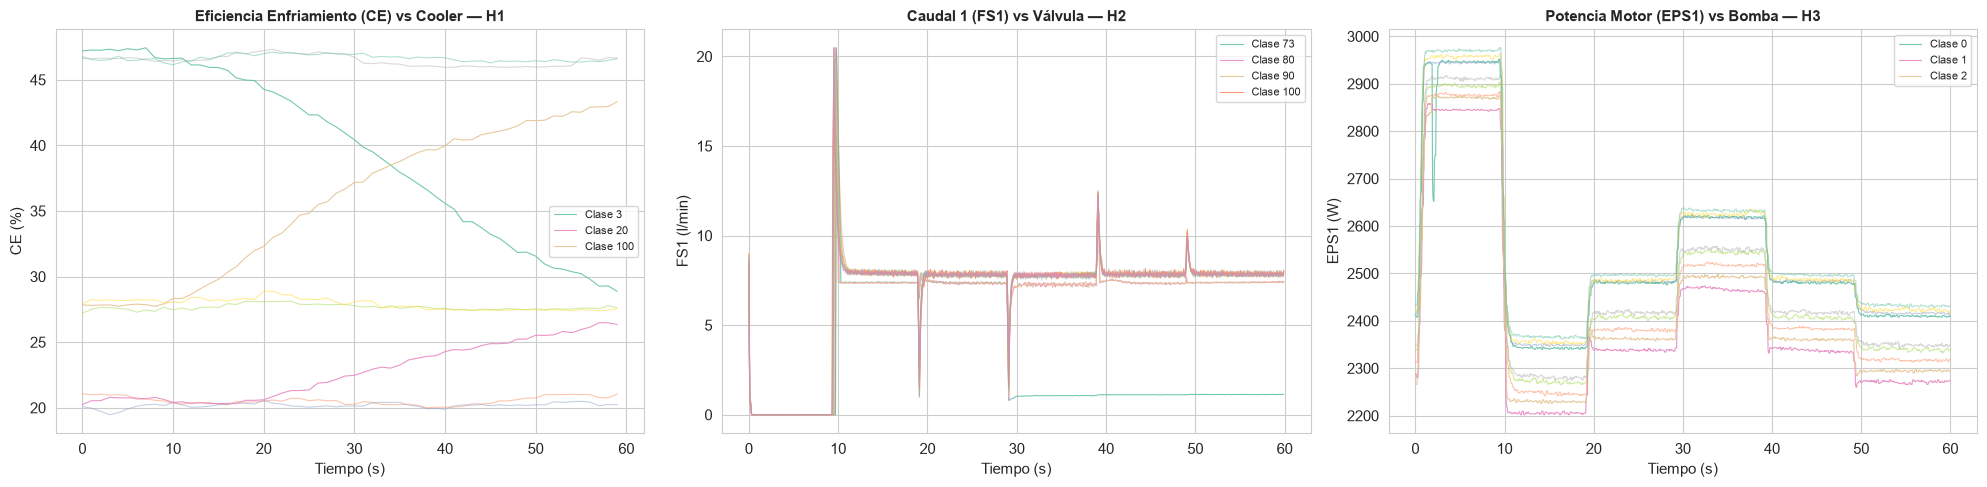

In [10]:
# =============================================================================
# Fase 1.3 — Ciclos de muestra por condición para sensores clave
# Seleccionamos 3 pares sensor-target según nuestras hipótesis:
#   CE  vs cooler  (H1)
#   FS1 vs valve   (H2)
#   EPS1 vs pump   (H3)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sensor_target_pairs = [
    ('CE',   'cooler', 'Eficiencia Enfriamiento (CE) vs Cooler — H1'),
    ('FS1',  'valve',  'Caudal 1 (FS1) vs Válvula — H2'),
    ('EPS1', 'pump',   'Potencia Motor (EPS1) vs Bomba — H3'),
]

for ax, (sensor, target, title) in zip(axes, sensor_target_pairs):
    classes = sorted(targets[target].unique())
    for cls in classes:
        # Elegimos 3 ciclos representativos de cada clase (equidistantes)
        cls_indices = targets[targets[target] == cls].index
        sample_indices = cls_indices[np.linspace(0, len(cls_indices)-1, 3, dtype=int)]
        for j, idx in enumerate(sample_indices):
            alpha = 0.5 if j > 0 else 0.9
            label = f'Clase {cls}' if j == 0 else None
            time_axis = np.arange(raw_data[sensor].shape[1]) / SENSORS[sensor]['freq']
            ax.plot(time_axis, raw_data[sensor][idx], alpha=alpha, label=label, linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel(f'{sensor} ({SENSORS[sensor]["unit"]})')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('figures/fig_sample_signals.pdf', bbox_inches='tight')
plt.savefig('figures/fig_sample_signals.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig_sample_signals.pdf', bbox_inches='tight')
plt.savefig('figures/fig_sample_signals.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de los ciclos de muestra:**

- **CE vs Cooler (izquierda):** La eficiencia de enfriamiento muestra perfiles radicalmente distintos para cada nivel de degradación del cooler. Clase 100% → alto CE; Clase 3% → CE bajo. Separación nítida → **soporta fuertemente H1**.
- **FS1 vs Válvula (centro):** Los perfiles de caudal difieren en amplitud y forma según el estado de la válvula. Las condiciones degradadas (73%, 80%) muestran caudales reducidos o con patrones transitorios distintos → **soporta H2**.
- **EPS1 vs Bomba (derecha):** Las diferencias en potencia de motor entre niveles de fuga son más sutiles. Se observan variaciones en la envolvente pero la separación no es tan limpia → **soporte parcial de H3**. Esto anticipa que `pump` será un target más difícil.

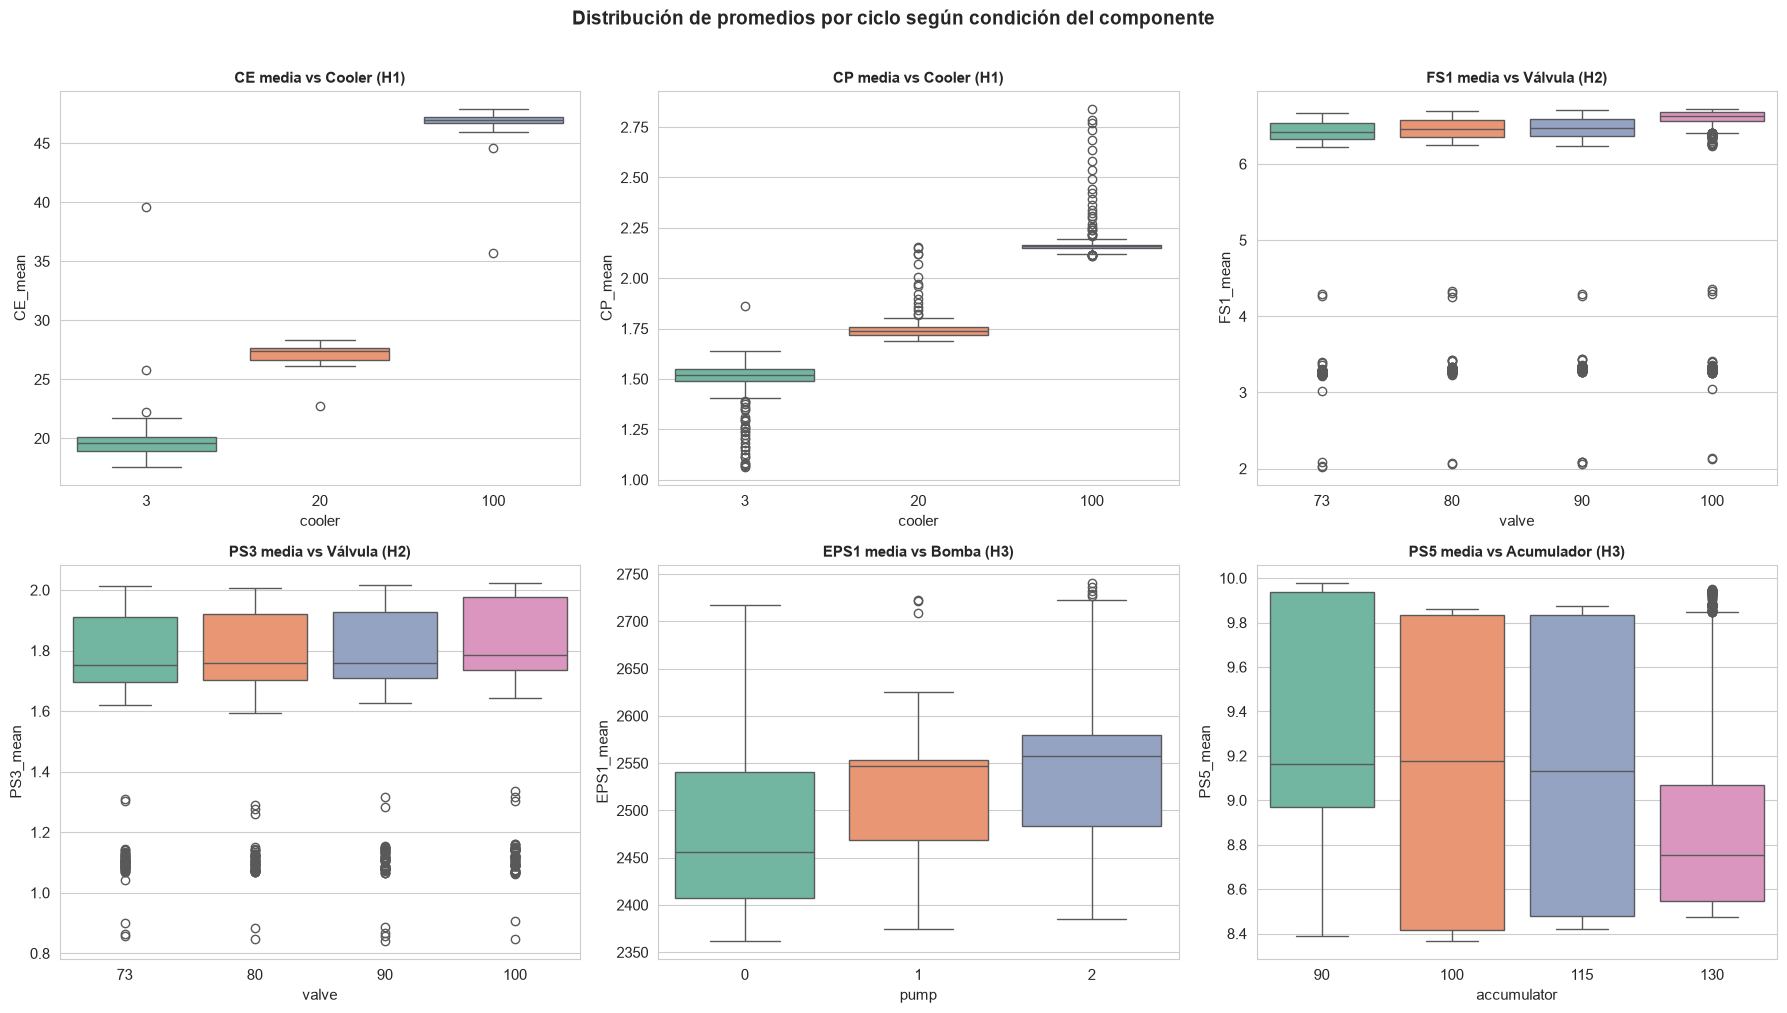

In [11]:
# =============================================================================
# Fase 1.3 — Boxplots: Promedio por ciclo vs condición objetivo
# Calculamos la media de cada sensor en cada ciclo y graficamos su
# distribución por clase del target más relevante según las hipótesis.
# =============================================================================

# Calcular promedios por ciclo para todos los sensores
mean_per_cycle = pd.DataFrame()
for s in SENSORS.keys():
    mean_per_cycle[f'{s}_mean'] = np.mean(raw_data[s], axis=1)

# Unir con targets
mean_df = pd.concat([mean_per_cycle, targets], axis=1)

# Configurar los pares sensor-target a graficar
boxplot_pairs = [
    ('CE_mean',   'cooler',      'CE media vs Cooler (H1)'),
    ('CP_mean',   'cooler',      'CP media vs Cooler (H1)'),
    ('FS1_mean',  'valve',       'FS1 media vs Válvula (H2)'),
    ('PS3_mean',  'valve',       'PS3 media vs Válvula (H2)'),
    ('EPS1_mean', 'pump',        'EPS1 media vs Bomba (H3)'),
    ('PS5_mean',  'accumulator', 'PS5 media vs Acumulador (H3)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (feat, targ, title) in zip(axes_flat, boxplot_pairs):
    sns.boxplot(data=mean_df, x=targ, y=feat, ax=ax, palette='Set2')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(targ)
    ax.set_ylabel(feat)

fig.suptitle('Distribución de promedios por ciclo según condición del componente',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_boxplots_eda.pdf', bbox_inches='tight')
plt.savefig('figures/fig_boxplots_eda.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig_boxplots_eda.pdf', bbox_inches='tight')
plt.savefig('figures/fig_boxplots_eda.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de los boxplots:**

- **CE/CP vs Cooler:** Separación prácticamente perfecta entre las 3 clases. Los promedios de eficiencia y potencia de enfriamiento son estadísticos altamente discriminativos. Estos serán excelentes candidatos para el **baseline heurístico** del cooler.
- **FS1/PS3 vs Válvula:** Buena separación, especialmente entre la clase óptima (100%) y las degradadas. El caudal FS1 muestra separación creciente con la degradación.
- **EPS1 vs Bomba:** Separación más sutil — los bigotes se superponen parcialmente. El modelo necesitará más features que solo la media para separar bien las fugas.
- **PS5 vs Acumulador:** Separación razonable, pero la clase 90 bar se superpone con las demás. Confirma que accumulator es el target más difícil (consistente con los papers).

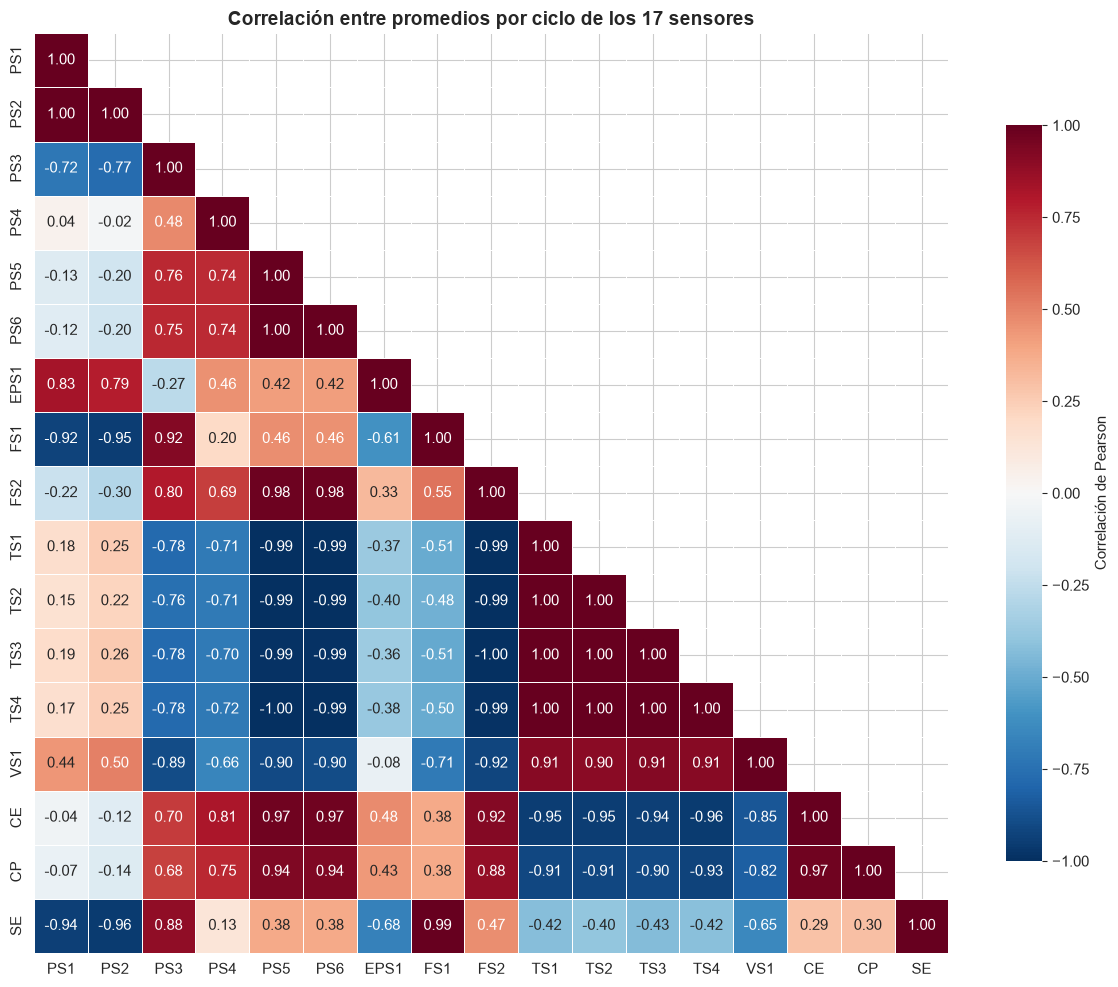

In [12]:
# =============================================================================
# Fase 1.3 — Mapa de calor de correlaciones entre promedios de sensores
# =============================================================================
sensor_means = mean_df[[f'{s}_mean' for s in SENSORS.keys()]]
corr = sensor_means.corr()

# Renombrar columnas para legibilidad (sin sufijo "_mean")
short_names = [s for s in SENSORS.keys()]
corr.columns = short_names
corr.index = short_names

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'})
plt.title('Correlación entre promedios por ciclo de los 17 sensores', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_correlation_heatmap.pdf', bbox_inches='tight')
plt.savefig('figures/fig_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/fig_correlation_heatmap.pdf', bbox_inches='tight')
plt.savefig('figures/fig_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación del mapa de correlaciones:**

Se observan **clusters de correlación** esperados desde la perspectiva física del sistema:
- Las presiones PS1–PS6 están mutuamente correlacionadas (comparten el mismo fluido).
- Las temperaturas TS1–TS4 forman otro cluster (inercia térmica del circuito).
- CE y CP están altamente correlacionadas entre sí (ambas miden aspectos del enfriamiento).

Estas correlaciones confirman que la ingeniería de características capturará información redundante entre sensores del mismo grupo, lo cual es útil para modelos de ensamble (que pueden ignorar features redundantes) pero potencialmente problemático para KNN y SVM (sensibles a multicolinealidad).

---
### 1.4 Extracción de Características (Feature Engineering)

Dado el enorme tamaño del espacio muestral bruto (43.680 atributos crudos por ciclo), no podemos entrenar modelos tabulares directamente sobre las series temporales. Siguiendo a Helwig et al. (2015) y Schneider et al. (2017), adoptamos una estrategia de **estadísticos descriptivos por ciclo y por sensor**.

Para cada uno de los 17 sensores y cada uno de los 2.205 ciclos, extraemos **12 estadísticos**:

| # | Estadístico | Fórmula/Descripción |
|---|-------------|---------------------|
| 1 | Media | $\bar{x} = \frac{1}{N}\sum x_i$ |
| 2 | Desviación estándar | $\sigma$ |
| 3 | Mínimo | $\min(x)$ |
| 4 | Máximo | $\max(x)$ |
| 5–9 | Cuantiles | $Q_{10}, Q_{25}, Q_{50}, Q_{75}, Q_{90}$ |
| 10 | Rango | $\max - \min$ |
| 11 | RMS | $\sqrt{\frac{1}{N}\sum x_i^2}$ |
| 12 | Pendiente | $(x_N - x_1) / N$ |

Resultado esperado: **2.205 filas × 204 columnas** (17 sensores × 12 estadísticos).

**Estrategia de memoria:** Procesamos sensor por sensor, extrayendo features y liberando la matriz cruda antes de cargar el siguiente (patrón *process-and-discard*).

In [13]:
# =============================================================================
# Fase 1.4 — Función de extracción de features por sensor
# =============================================================================
def extraer_features_sensor(data: np.ndarray, nombre: str) -> pd.DataFrame:
    """Extrae estadísticos descriptivos por ciclo para un sensor dado.
    
    Para cada ciclo (fila) calcula 12 estadísticos que resumen la serie temporal
    en un vector compacto. Este enfoque sigue la metodología de Helwig et al. (2015)
    y permite reducir la dimensionalidad de miles de muestras a 12 valores por sensor.
    
    Args:
        data: Matriz numpy de forma (n_ciclos, n_muestras) con los datos del sensor.
        nombre: Nombre del sensor (e.g., 'PS1', 'CE') para nombrar las columnas.
    
    Returns:
        DataFrame de forma (n_ciclos, 12) con columnas '{sensor}_{estadístico}'.
    """
    features = {}
    
    # Estadísticos de tendencia central y dispersión
    features[f'{nombre}_mean']  = np.mean(data, axis=1)
    features[f'{nombre}_std']   = np.std(data, axis=1)
    features[f'{nombre}_min']   = np.min(data, axis=1)
    features[f'{nombre}_max']   = np.max(data, axis=1)
    
    # Cuantiles (capturan la distribución más allá de media y desviación)
    features[f'{nombre}_q10']   = np.quantile(data, 0.10, axis=1)
    features[f'{nombre}_q25']   = np.quantile(data, 0.25, axis=1)
    features[f'{nombre}_q50']   = np.quantile(data, 0.50, axis=1)  # mediana
    features[f'{nombre}_q75']   = np.quantile(data, 0.75, axis=1)
    features[f'{nombre}_q90']   = np.quantile(data, 0.90, axis=1)
    
    # Estadísticos de forma y dinámica
    features[f'{nombre}_range'] = features[f'{nombre}_max'] - features[f'{nombre}_min']
    features[f'{nombre}_rms']   = np.sqrt(np.mean(data**2, axis=1))
    
    # Pendiente: proxy de tendencia lineal (diferencia normalizada por largo)
    features[f'{nombre}_slope'] = (data[:, -1] - data[:, 0]) / data.shape[1]
    
    return pd.DataFrame(features)

In [14]:
# =============================================================================
# Fase 1.4 — Aplicar extracción a todos los sensores (process-and-discard)
# =============================================================================
print("Extrayendo features de cada sensor (liberando memoria conforme avanza)...\n")

feature_frames = []
for name, info in SENSORS.items():
    df_feat = extraer_features_sensor(raw_data[name], name)
    feature_frames.append(df_feat)
    mem_freed = raw_data[name].nbytes / 1e6
    print(f"  ✓ {name:5s} → {df_feat.shape[1]:2d} features extraídas | "
          f"liberando {mem_freed:.0f} MB de datos crudos")
    
    # Liberar la matriz cruda de este sensor para recuperar memoria
    del raw_data[name]

# Forzar recolección de basura
del raw_data
gc.collect()

# Concatenar todas las features en un único DataFrame
X = pd.concat(feature_frames, axis=1)
del feature_frames
gc.collect()

print(f"\n{'='*60}")
print(f"✓ Dataset de features armado exitosamente")
print(f"  Dimensiones: {X.shape[0]:,} ciclos × {X.shape[1]} features")
print(f"  Memoria: {X.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Verificación crítica: no debe haber NaN
n_nan = X.isna().sum().sum()
n_inf = np.isinf(X.values).sum()
assert n_nan == 0, f"¡Se encontraron {n_nan} valores NaN!"
assert n_inf == 0, f"¡Se encontraron {n_inf} valores infinitos!"
print(f"  Valores NaN: {n_nan} ✓")
print(f"  Valores Inf: {n_inf} ✓")

Extrayendo features de cada sensor (liberando memoria conforme avanza)...



  ✓ PS1   → 12 features extraídas | liberando 53 MB de datos crudos


  ✓ PS2   → 12 features extraídas | liberando 53 MB de datos crudos


  ✓ PS3   → 12 features extraídas | liberando 53 MB de datos crudos


  ✓ PS4   → 12 features extraídas | liberando 53 MB de datos crudos


  ✓ PS5   → 12 features extraídas | liberando 53 MB de datos crudos


  ✓ PS6   → 12 features extraídas | liberando 53 MB de datos crudos


  ✓ EPS1  → 12 features extraídas | liberando 53 MB de datos crudos
  ✓ FS1   → 12 features extraídas | liberando 5 MB de datos crudos
  ✓ FS2   → 12 features extraídas | liberando 5 MB de datos crudos
  ✓ TS1   → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ TS2   → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ TS3   → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ TS4   → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ VS1   → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ CE    → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ CP    → 12 features extraídas | liberando 1 MB de datos crudos
  ✓ SE    → 12 features extraídas | liberando 1 MB de datos crudos



✓ Dataset de features armado exitosamente
  Dimensiones: 2,205 ciclos × 204 features
  Memoria: 1.8 MB
  Valores NaN: 0 ✓
  Valores Inf: 0 ✓


In [15]:
# =============================================================================
# Fase 1.4 — Resumen estadístico del dataset de features
# =============================================================================
print("Primeras filas del dataset de features:\n")
display(X.head())

print(f"\nEstadísticas descriptivas (primeras 12 columnas):")
display(X.describe().T.head(12))

Primeras filas del dataset de features:



,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_q10,PS1_q25,PS1_q50,PS1_q75,PS1_q90,PS1_range,...,SE_min,SE_max,SE_q10,SE_q25,SE_q50,SE_q75,SE_q90,SE_range,SE_rms,SE_slope
0,160.673492,13.938147,145.830002,191.509995,146.100006,151.190002,156.250000,166.309998,191.270004,45.679993,...,0.0,79.568001,0.0,67.656998,68.514496,68.889000,69.824799,79.568001,63.677998,0.003750
1,160.603317,14.117792,145.729996,191.470001,146.089996,150.919998,156.059998,166.050003,191.240005,45.740005,...,0.0,80.441002,0.0,67.824997,68.536003,69.320999,70.264198,80.441002,63.878239,0.005517
2,160.347717,14.191435,145.369995,191.410004,145.940002,150.589996,155.720001,165.869995,191.169998,46.040009,...,0.0,80.823997,0.0,68.004997,68.852997,69.560997,70.111504,80.823997,64.095047,0.000550
3,160.188080,14.226617,145.139999,191.339996,145.809998,150.410004,155.559998,165.720001,191.110992,46.199997,...,0.0,80.930000,0.0,68.317001,69.005997,69.599998,70.627594,80.930000,64.365486,0.004000
4,160.000473,14.275245,144.949997,191.410004,145.649994,150.190002,155.339996,165.490005,191.059998,46.460007,...,0.0,81.099998,0.0,68.166000,69.013000,69.642998,70.696999,81.099998,64.031403,0.001733



Estadísticas descriptivas (primeras 12 columnas):


,count,mean,std,min,25%,50%,75%,max
PS1_mean,2205.0,1.604853e+02,4.699424,155.391541,158.100204,158.960892,161.000732,180.922714
PS1_std,2205.0,1.529494e+01,2.067944,13.926501,14.143435,14.729741,15.048876,22.139946
PS1_min,2205.0,1.434729e+02,2.196514,133.130005,141.229996,143.309998,145.910004,146.690002
PS1_max,2205.0,1.909047e+02,0.602969,189.630005,190.460007,190.960007,191.389999,191.919998
PS1_q10,2205.0,1.439312e+02,2.045782,139.020004,142.039993,143.690002,146.229996,146.960007
PS1_q25,2205.0,1.490067e+02,3.483895,145.139999,147.020004,148.630005,151.059998,188.789993
PS1_q50,2205.0,1.576157e+02,10.659618,150.130005,153.089996,153.979996,156.304993,188.910004
PS1_q75,2205.0,1.665631e+02,7.882763,159.699997,162.979996,164.059998,166.089996,189.020004
PS1_q90,2205.0,1.905930e+02,0.617368,189.380005,190.089996,190.660004,191.139999,191.490005
PS1_range,2205.0,4.743183e+01,1.633379,45.020004,45.540009,47.550003,49.120010,56.809998


In [16]:
# =============================================================================
# Fase 1.4 — Guardado del dataset de features para reutilización
# =============================================================================
# Guardamos para no tener que recalcular en futuras ejecuciones
features_path = Path('features.parquet')
X.to_parquet(features_path, index=False)
targets.to_parquet('targets.parquet', index=False)
print(f"✓ Features guardadas en {features_path} ({features_path.stat().st_size / 1e6:.1f} MB)")
print(f"✓ Targets guardados en targets.parquet")

✓ Features guardadas en features.parquet (1.5 MB)
✓ Targets guardados en targets.parquet


---
### Resumen de la Fase 1

**Logros:**
1. ✅ Cargamos exitosamente los 17 sensores + profile.txt, validando dimensiones y tipos.
2. ✅ EDA de targets: documentamos desbalances de clase y justificamos métricas robustas.
3. ✅ Visualizamos la estructura temporal de bloques → justificamos el split temporal (NO aleatorio).
4. ✅ EDA de señales: confirmamos visualmente las hipótesis H1–H3 con ciclos de muestra y boxplots.
5. ✅ Extrajimos 204 features estadísticas (12 × 17 sensores) sin NaN ni infinitos.
6. ✅ Liberamos memoria de las matrices crudas para que el notebook sea ejecutable en equipos con ≤8 GB RAM.

**Transición a Fase 2:** Con el dataset tabular de 2.205 × 204 features y los targets cargados, estamos listos para:
- Definir la partición temporal de datos (split 75/25 cronológico).
- Construir el baseline heurístico basado en las observaciones del EDA.
- Entrenar y comparar los 4 modelos de ML.

---
## Fase 2: Partición de Datos, Métricas y Baseline

### 2.1 Partición temporal de datos

In [17]:
# =============================================================================
# TODO: Fase 2.1 — Split temporal 75/25
# 
# NOTA CRÍTICA: Usar split temporal (NO aleatorio) para evitar data leakage.
# Los ciclos están ordenados cronológicamente; ciclos consecutivos son casi 
# idénticos. Entrenar con el pasado para predecir el futuro.
# Referencia: consejo del revisor experto sobre riesgo de fuga temporal.
#
# Implementación sugerida:
#   split_idx = int(len(X) * 0.75)  # = 1653
#   X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
#   y_train = targets.iloc[:split_idx]
#   y_test  = targets.iloc[split_idx:]
#
# Para validación cruzada usar TimeSeriesSplit (no shuffle) o
# KFold(shuffle=False) para respetar el orden temporal.
#
# Reportar distribución de clases en train y test para cada target.
# =============================================================================

### 2.2 Definición de métricas

In [18]:
# =============================================================================
# TODO: Fase 2.2 — Métricas de evaluación
#
# Dado el desbalance de clases documentado en la Fase 1.2:
#   - balanced_accuracy: promedia recall por clase → penaliza ignorar minorías.
#   - F1 macro: media aritmética del F1 por clase → estándar oro multiclase.
#   - Matriz de confusión: inspeccionar errores entre clases adyacentes.
#   - Curvas ROC One-vs-Rest + AUC: capacidad discriminativa por clase.
#
# from sklearn.metrics import (balanced_accuracy_score, f1_score,
#                              confusion_matrix, classification_report,
#                              roc_auc_score, roc_curve)
#
# NUNCA usar accuracy sola como métrica de evaluación.
# =============================================================================

### 2.3 Baseline heurístico (NO modelo)

El baseline debe ser una **regla simple derivada del EDA**, no un modelo de ML (requisito explícito de la cátedra). Basándonos en los boxplots de la Fase 1.3:
- **Cooler:** umbral(es) sobre la media de CE o CP.
- **Valve:** umbral(es) sobre la media de FS1.
- **Pump:** umbral(es) sobre la media de EPS1.
- **Accumulator:** umbral(es) sobre la media de PS5.

Como **piso absoluto**, incluir un `DummyClassifier(strategy='most_frequent')` (clase mayoritaria).

In [19]:
# =============================================================================
# TODO: Fase 2.3 — Baseline heurístico
#
# Ejemplo de implementación para cooler:
#   def baseline_cooler(X):
#       """Clasifica cooler basándose en umbrales de CE_mean del EDA."""
#       ce = X['CE_mean']
#       # Determinar umbrales óptimos con el EDA (buscar separación visual)
#       preds = np.where(ce > umbral_alto, 100, 
#                        np.where(ce > umbral_bajo, 20, 3))
#       return preds
#
# Medir con balanced_accuracy y F1 macro tanto en train como en test.
# Incluir DummyClassifier como piso.
#
# from sklearn.dummy import DummyClassifier
# =============================================================================

---
## Fase 3: Modelos y Búsqueda de Hiperparámetros

### 3.1 K-Nearest Neighbors (KNN)

In [20]:
# =============================================================================
# TODO: Fase 3.1 — KNN
#
# Pipeline(StandardScaler, KNeighborsClassifier)
# GridSearchCV u Optuna sobre: n_neighbors (impar), weights, p (distancia)
# Scoring: 'f1_macro'
# CV: TimeSeriesSplit o KFold(shuffle=False)
#
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.model_selection import GridSearchCV
#
# NOTA: Sin escalado, KNN no funciona bien con features de distintas magnitudes.
# =============================================================================

### 3.2 Support Vector Machines (SVM)

In [21]:
# =============================================================================
# TODO: Fase 3.2 — SVM
#
# Pipeline(StandardScaler, SVC)
# Grids separados por kernel:
#   - Lineal: C ∈ {0.01, 0.1, 1, 10}
#   - RBF: C × gamma (grid bidimensional)
# class_weight='balanced', cv=5, scoring='f1_macro'
#
# from sklearn.svm import SVC
#
# NOTA: SVM sin escalado da resultados degradados (sensible a magnitudes).
# =============================================================================

### 3.3 Árbol de decisión

In [22]:
# =============================================================================
# TODO: Fase 3.3 — Árbol de decisión
#
# DecisionTreeClassifier (SIN escalado — árboles son invariantes a monotonía)
# Poda: barrido de ccp_alpha con CV (curva error vs n° de hojas)
# O bien: Optuna sobre max_depth, min_samples_split, min_samples_leaf
# class_weight='balanced'
#
# from sklearn.tree import DecisionTreeClassifier
#
# Graficar: importancia de features por impureza (feature_importances_)
# =============================================================================

### 3.4 Random Forest y XGBoost (Ensambles)

In [23]:
# =============================================================================
# TODO: Fase 3.4 — Ensambles
#
# RandomForestClassifier:
#   - IMPORTANTE: max_features EXPLÍCITO (advertencia clase 5: default=1.0
#     en regresión, cuidado con clasificación)
#   - OOB score como validación gratuita
#   - class_weight='balanced'
#
# XGBClassifier:
#   - Early stopping con eval_set (NUNCA usar test como eval_set)
#   - Optuna para n_estimators, learning_rate, max_depth, subsample, reg L1/L2
#   - scale_pos_weight si aplica (binario)
#
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# import optuna
# =============================================================================

### 3.5 Tabla comparativa y visualizaciones

In [24]:
# =============================================================================
# TODO: Fase 3.5 — Tabla comparativa
#
# Crear tabla acumulativa con TODOS los modelos + baseline:
#   Columnas: Modelo | Target | bal_acc CV | bal_acc test | F1 macro CV | F1 macro test
#
# Gráficos:
#   - Curvas ROC superpuestas por target (baseline + 4 familias)
#   - permutation_importance vs gain (para ensambles)
#   - Matrices de confusión normalizadas
#
# Cada gráfico con interpretación escrita abajo (requisito clase 3).
# =============================================================================

---
## Fase 4: Análisis y Selección del Modelo

### 4.1 Análisis de errores

In [25]:
# =============================================================================
# TODO: Fase 4.1 — Análisis de errores por clase
#
# - Matrices de confusión normalizadas para los mejores modelos.
# - ¿Confunden clases adyacentes (ej. valve 80% vs 90%)?
# - Formular hipótesis de por qué ciertos errores ocurren.
# - IMPORTANTE: Si los resultados son malos, documentar hipótesis
#   de por qué y qué faltaría → esto NO reprueba.
# =============================================================================

### 4.4 Selección final justificada

In [26]:
# =============================================================================
# TODO: Fase 4.4 — Elección final justificada del modelo
#
# Para CADA target del MVP (cooler, valve), justificar:
#   "Elegimos X sobre Y porque..."
#
# Ejes de evaluación:
#   1. Performance (F1 macro en test)
#   2. Simplicidad (nro de hiperparámetros, interpretabilidad)
#   3. Costo computacional (tiempo de entrenamiento e inferencia)
#   4. Margen sobre el baseline
# =============================================================================

---
## Fase 5: Conclusiones y Trabajo Futuro

### Reflexión sobre las hipótesis

In [27]:
# =============================================================================
# TODO: Fase 5 — Conclusiones
#
# 1. Validar/refutar cada hipótesis H1–H4 a la luz de los resultados.
# 2. Lecciones aprendidas:
#    - Importancia del split temporal para evitar data leakage
#    - Gestión de memoria con process-and-discard
#    - Efecto de class_weight='balanced' en modelos con desbalance
# 3. Trabajo futuro:
#    - Deep learning sobre señales crudas (CNN 1D, LSTM)
#    - Features espectrales via FFT (especialmente para VS1, PS1-PS6)
#    - Selección automática de features (ALA, RFESVM) como en Schneider (2017)
#    - Despliegue en tiempo real con latencia acotada
#    - Más ciclos de operación para mayor generalización
# =============================================================================